Linear Regression from Scratch using pytorch



In [2]:
import torch
import numpy as np


In [3]:
x=np.array([[1,2,3],[4,5,6],[7,8,9]],dtype="float32")
y=np.array([[43,45],[345.67,23],[35,90]],dtype="float32")
inputs=torch.from_numpy(x)
target=torch.from_numpy(y)


In [4]:
w = torch.randn(2, 3, requires_grad = True)
b = torch.randn(2, requires_grad = True)


In [5]:
def model(x):
  return  x@w.t()+b

In [6]:
preds=model(inputs)
print(preds)

tensor([[  0.7169,  -4.2028],
        [ -0.1069,  -8.3442],
        [ -0.9308, -12.4856]], grad_fn=<AddBackward0>)


In [7]:
def MSE(y,y_hat):
  diff=y-y_hat
  return torch.sum(diff*diff)/diff.numel()

In [8]:
loss = MSE(target, preds)
print(loss)

tensor(22757.8730, grad_fn=<DivBackward0>)


In [9]:
loss.backward()

In [10]:
print(w)
print(w.grad)

tensor([[-1.2922,  0.6425,  0.3751],
        [-0.1438,  0.4897, -1.7264]], requires_grad=True)
tensor([[-558.9687, -700.2990, -841.6292],
        [-297.3264, -358.3372, -419.3481]])


In [11]:
print(b)
print(b.grad)

tensor([-0.4011,  0.1407], requires_grad=True)
tensor([-141.3302,  -61.0109])


In [12]:
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [13]:
preds = model(inputs)

print(preds)


loss = MSE(target, preds)
print(loss)

tensor([[  0.7169,  -4.2028],
        [ -0.1069,  -8.3442],
        [ -0.9308, -12.4856]], grad_fn=<AddBackward0>)
tensor(22757.8730, grad_fn=<DivBackward0>)


In [14]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[-558.9687, -700.2990, -841.6292],
        [-297.3264, -358.3372, -419.3481]])
tensor([-141.3302,  -61.0109])


In [15]:
learning_rate = 1e-5

with torch.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [16]:
print(w)
print(b)

tensor([[-1.2866,  0.6495,  0.3835],
        [-0.1408,  0.4933, -1.7222]], requires_grad=True)
tensor([-0.3997,  0.1413], requires_grad=True)


In [17]:
for i in range(4):
  preds = model(inputs)
  loss = MSE(target, preds)
  loss.backward()
  with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5

    w.grad.zero_()
    b.grad.zero_()
  print(f"Epochs({i}/{100}) & Loss {loss}")

Epochs(0/100) & Loss 22738.607421875
Epochs(1/100) & Loss 22719.373046875
Epochs(2/100) & Loss 22700.181640625
Epochs(3/100) & Loss 22681.025390625


In [18]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(22661.9082, grad_fn=<DivBackward0>)


In [19]:
from math import sqrt
sqrt(loss)

/tmp/ipykernel_599/3167310485.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  sqrt(loss)


150.53872658928998

Fashion MNIST Neural Net example using Pytorch

In [20]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

In [21]:
# Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'data',
    train= True,
    download = True,
    transform = ToTensor(),
)

# Download test data from open datasets

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download = True,
    transform = ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.71MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.2MB/s]


In [22]:
batch_size = 64

# Create data loaders

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
  print("Shape of X [N, C, H, W] ", X.shape)
  print("Shape of y: ", y.shape, y.dtype)
  break

Shape of X [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [23]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [24]:
# Define the NN Model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    # Hidden Layers with ReLU activation function
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10) # Output layer
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model= NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [25]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [26]:
# Model Training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device) # related to gpu computation

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # BackPropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch %100 ==0 :
      loss, current = loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [27]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)

      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss {test_loss}\n")

In [29]:
#save model
torch.save(model.state_dict(), "model.pth")
print("Saved model state to model.pth")

Saved model state to model.pth


In [30]:
## Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]


model.eval()

x, y = test_data[10][0], test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")




Predicted: Pullover Actual: Coat


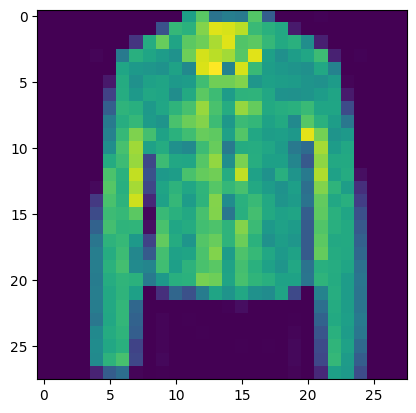

In [31]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()